STARMap Sample 1


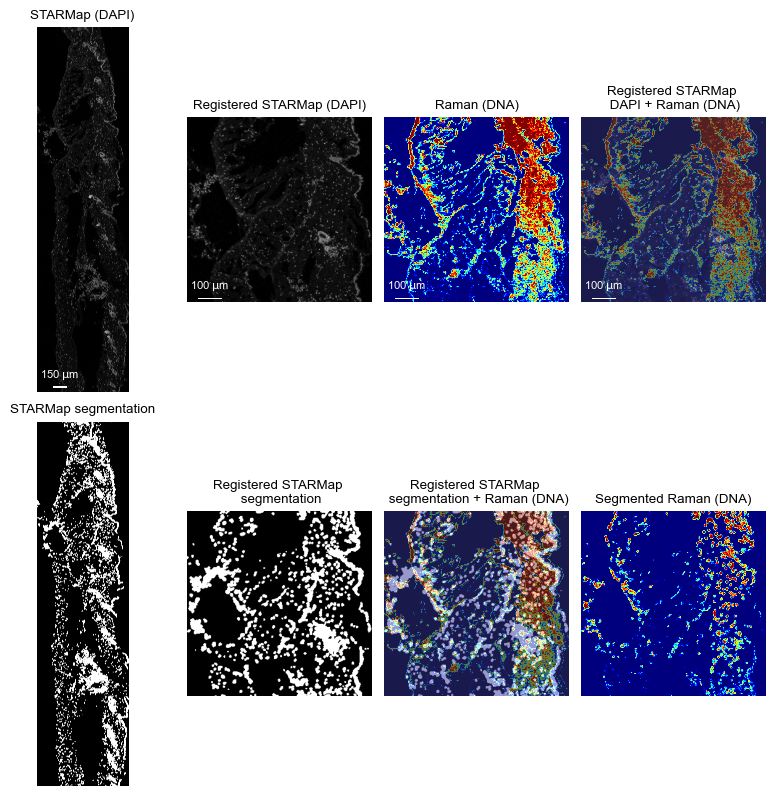

Number of DAPI segmented cells  7970
Number of STARmap captured cells (after QC)  6147
Number of STARmap-Raman captured cells  1407
Number of p16 positive cells  71
Number of p21 positive cells  20
Number of p16 or p21 positive cells  89
Number of p16 and p21 positive cells  0


/var/folders/yt/m1gj02c17sq_h2w0s6k3jtm00000gn/T/ipykernel_21558/1738961854.py:213: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cell_df = cell_df.fillna(False)


STARMap Sample 2


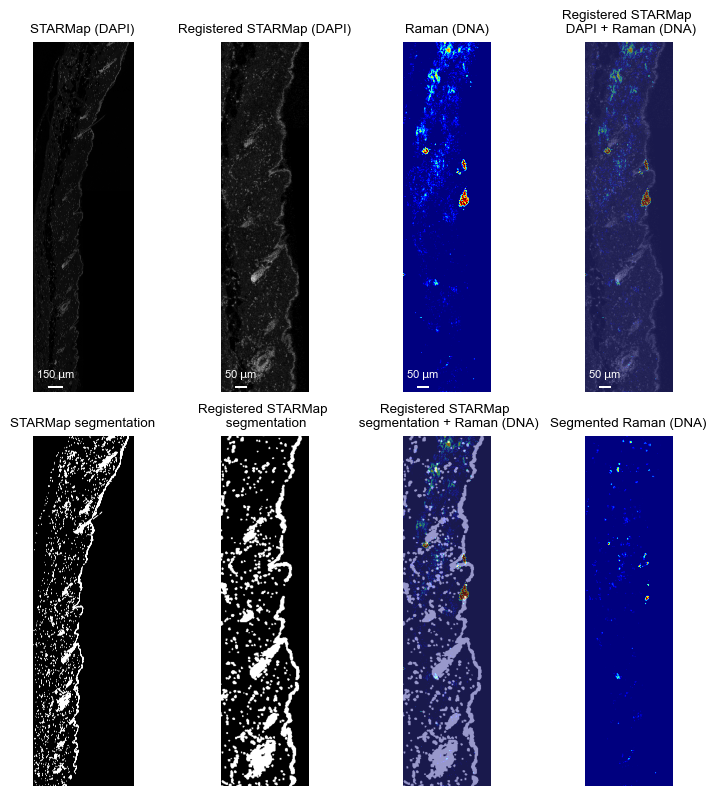

Number of DAPI segmented cells  4366
Number of STARmap captured cells (after QC)  3297
Number of STARmap-Raman captured cells  1357
Number of p16 positive cells  71
Number of p21 positive cells  38
Number of p16 or p21 positive cells  106
Number of p16 and p21 positive cells  0
STARMap Sample 3


/var/folders/yt/m1gj02c17sq_h2w0s6k3jtm00000gn/T/ipykernel_21558/1738961854.py:213: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cell_df = cell_df.fillna(False)


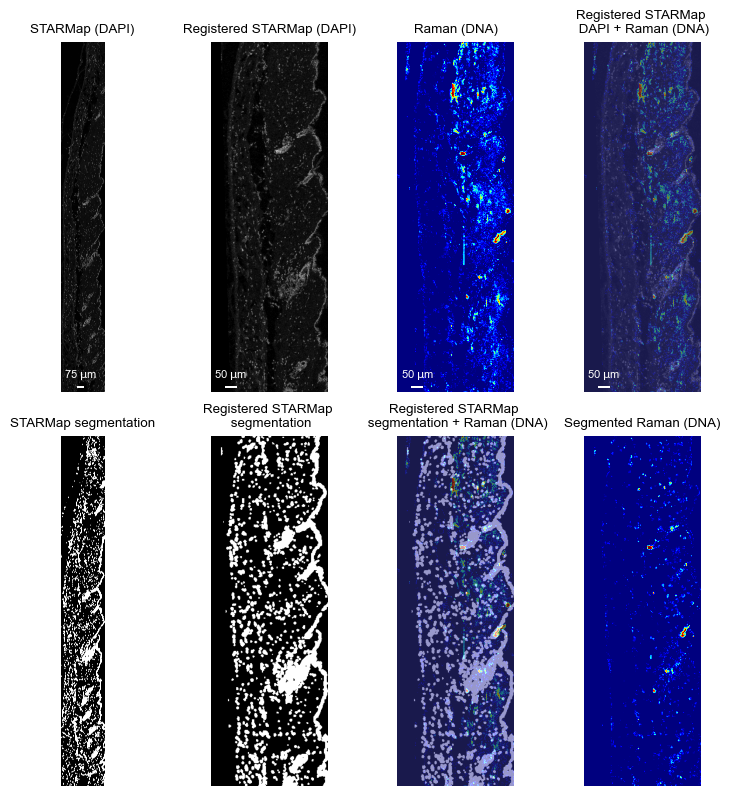

Number of DAPI segmented cells  5557
Number of STARmap captured cells (after QC)  3709
Number of STARmap-Raman captured cells  1784
Number of p16 positive cells  43
Number of p21 positive cells  33
Number of p16 or p21 positive cells  70
Number of p16 and p21 positive cells  0
STARMap Sample 4


/var/folders/yt/m1gj02c17sq_h2w0s6k3jtm00000gn/T/ipykernel_21558/1738961854.py:213: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cell_df = cell_df.fillna(False)


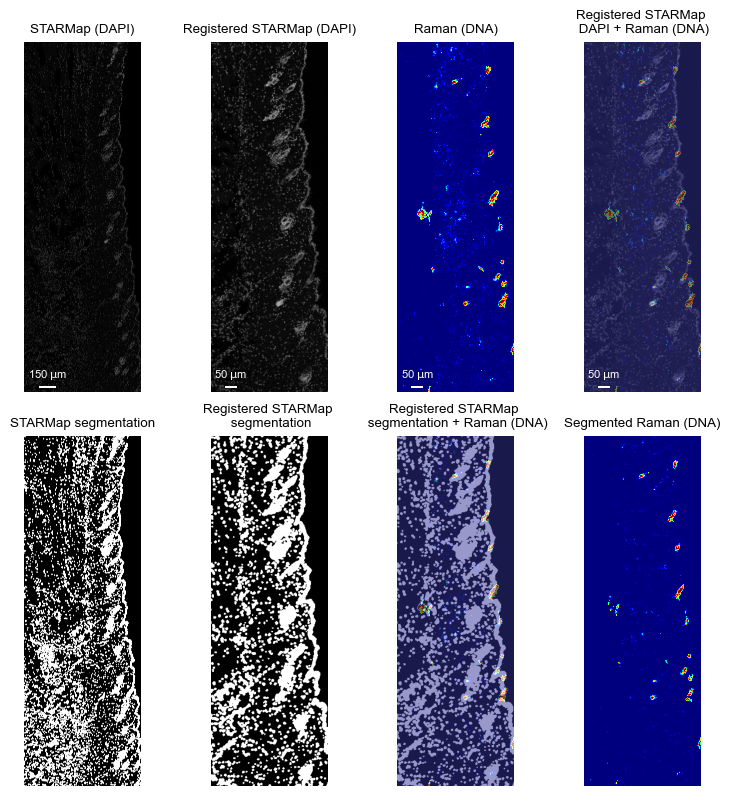

Number of DAPI segmented cells  11546
Number of STARmap captured cells (after QC)  7119
Number of STARmap-Raman captured cells  2594
Number of p16 positive cells  35
Number of p21 positive cells  23
Number of p16 or p21 positive cells  56
Number of p16 and p21 positive cells  0


/var/folders/yt/m1gj02c17sq_h2w0s6k3jtm00000gn/T/ipykernel_21558/1738961854.py:213: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cell_df = cell_df.fillna(False)


STARMap Sample 5


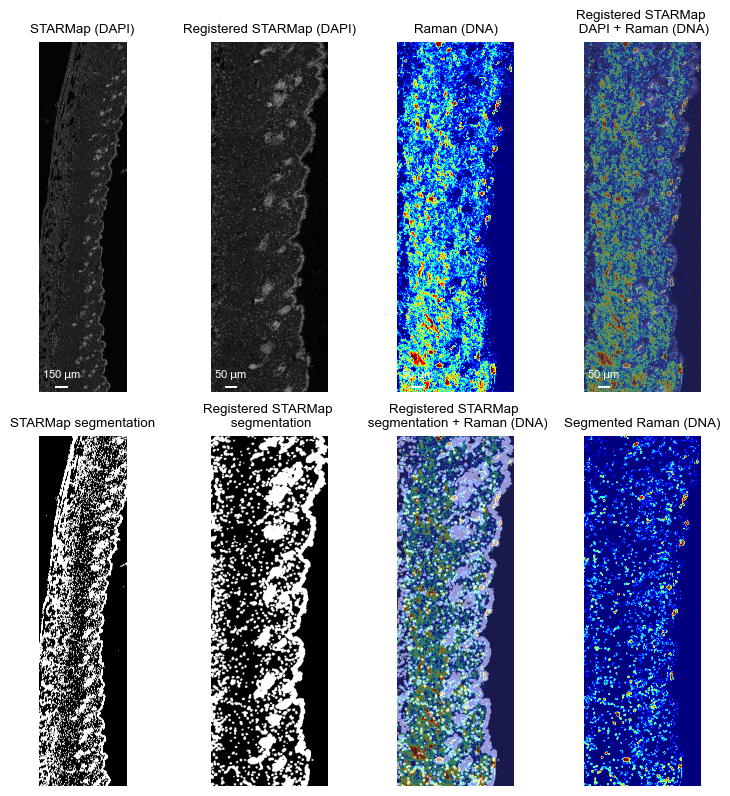

Number of DAPI segmented cells  11453
Number of STARmap captured cells (after QC)  5440
Number of STARmap-Raman captured cells  1697
Number of p16 positive cells  84
Number of p21 positive cells  59
Number of p16 or p21 positive cells  127
Number of p16 and p21 positive cells  0
STARMap Sample 6


/var/folders/yt/m1gj02c17sq_h2w0s6k3jtm00000gn/T/ipykernel_21558/1738961854.py:213: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cell_df = cell_df.fillna(False)


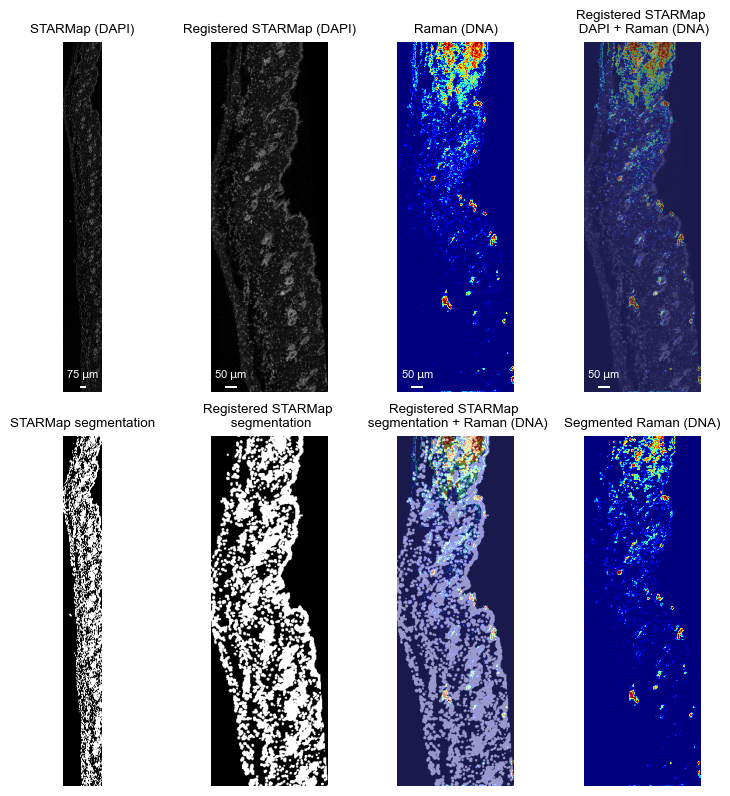

Number of DAPI segmented cells  9500
Number of STARmap captured cells (after QC)  6024
Number of STARmap-Raman captured cells  2230
Number of p16 positive cells  33
Number of p21 positive cells  50
Number of p16 or p21 positive cells  81
Number of p16 and p21 positive cells  0


/var/folders/yt/m1gj02c17sq_h2w0s6k3jtm00000gn/T/ipykernel_21558/1738961854.py:213: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cell_df = cell_df.fillna(False)


In [4]:
import cv2
import glob
import numpy as np
import pandas as pd
import scipy.io
from scipy.ndimage import rotate
from skimage import transform as tf
from skimage.transform import warp
import scipy.io
import cv2
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar

wave_number = scipy.io.loadmat('mouse_skin/wavenumbers.mat')['wavenumber'][0][413:1286].round(0).astype(np.int16)

all_sample_path = [ 
                    './mouse_skin/Sample 1/STARmap/',
                    './mouse_skin/Sample 2/STARmap/',
                    './mouse_skin/Sample 3/STARmap/',
                    './mouse_skin/Sample 4/STARmap/',
                    './mouse_skin/Sample 5/STARmap/',
                    './mouse_skin/Sample 6/STARmap/',
                    ]

for sample_path in all_sample_path:

    raman_image_name = glob.glob(sample_path + '*_T333.mat')
    tranform_matrix_name = glob.glob(sample_path + 'matrix_*.mat')
    starmap_dapi_name = glob.glob(sample_path + '*_v3.tif')
    starmap_segmentation_name = glob.glob(sample_path + '*segmentation.tif')
    raman_bmp_name = glob.glob(sample_path + '*.bmp')
    gene_expression_name = glob.glob(sample_path + '*_v1.txt')
    cell_type_name = glob.glob(sample_path + '*_Annotation.txt')
    # senmayo_name = glob.glob(sample_path + '*GSVA_*.txt')

    starmap_image = cv2.imread(starmap_dapi_name[0], -1) 
    raman_image = cv2.imread(raman_bmp_name[0], cv2.IMREAD_GRAYSCALE)
    starmap_mask = cv2.imread(starmap_segmentation_name[0], -1)

    t = scipy.io.loadmat(tranform_matrix_name[0])['matrix']
    tform = tf.AffineTransform(matrix=t)
    # Apply the transformation
    aligned_starmap_image = warp(starmap_image, tform.inverse, output_shape=raman_image.shape, order=0)
    aligned_starmap_mask = warp(starmap_mask, tform.inverse, output_shape=raman_image.shape, order=0, preserve_range=True).astype(starmap_mask.dtype)

    # Add the scale bar (you can specify the pixel size and units)

    # print name
    print('STARMap Sample ' + sample_path.split('/')[2].split(' ')[1])
    
    plt.figure(figsize=(8, 8))

    # set font size
    plt.rcParams.update({'font.size': 8})
    # set frnt style
    plt.rcParams.update({'font.family': 'Arial'})



    plt.subplot(2, 4, 1)
    plt.axis('off')
    starmap_scalebar = ScaleBar(0.284, 
                        'um',
                        scale_loc="top", 
                        font_properties={'size':8},
                        sep=3,
                        width_fraction=0.006,
                        location='lower left',
                        color='white',
                        length_fraction=0.15,
                        frameon=False)  # 1 pixel = pixel_size units (e.g., micrometers)
    plt.gca().add_artist(starmap_scalebar)
    plt.title('STARMap (DAPI)')
    plt.imshow(starmap_image, cmap='gray')


    plt.subplot(2, 4, 2)
    plt.axis('off')
    plt.title('Registered STARMap (DAPI)')

    raman_scalebar = ScaleBar(2.5, 
                        'um',
                        scale_loc="top", 
                        font_properties={'size':8},
                        sep=3,
                        width_fraction=0.006,
                        location='lower left',
                        color='white',
                        length_fraction=0.15,
                        frameon=False)  # 1 pixel = pixel_size units (e.g., micrometers)
    plt.gca().add_artist(raman_scalebar)



    plt.imshow(aligned_starmap_image, cmap='gray')
    plt.subplot(2, 4, 3)
    plt.axis('off')
    plt.title('Raman (DNA)')
    raman_scalebar = ScaleBar(2.5, 
                        'um',
                        scale_loc="top", 
                        font_properties={'size':8},
                        sep=3,
                        width_fraction=0.006,
                        location='lower left',
                        color='white',
                        length_fraction=0.15,
                        frameon=False)  # 1 pixel = pixel_size units (e.g., micrometers)
    plt.gca().add_artist(raman_scalebar)
    plt.imshow(raman_image, cmap='jet')
    plt.subplot(2, 4, 4)
    plt.axis('off')
    plt.title('Registered STARMap \n DAPI + Raman (DNA)')

    raman_scalebar = ScaleBar(2.5, 
                        'um',
                        scale_loc="top", 
                        font_properties={'size':8},
                        sep=3,
                        width_fraction=0.006,
                        location='lower left',
                        color='white',
                        length_fraction=0.15,
                        frameon=False)  # 1 pixel = pixel_size units (e.g., micrometers)
    plt.gca().add_artist(raman_scalebar)

    # set the alpha channel to 0.5
    plt.imshow(raman_image,  cmap='jet', alpha=0.8)
    plt.imshow(aligned_starmap_image, cmap='gray', alpha=0.5)
    # plt.show()

    # plt.figure(figsize=(15, 5))
    plt.subplot(2, 4, 5)
    plt.axis('off')
    plt.title('STARMap segmentation')
    # plt.imshow(starmap_mask>0)
    seg_fig = starmap_mask>0
    seg_fig[seg_fig>0] = 255
    plt.imshow(seg_fig, cmap='gray')
    plt.subplot(2, 4, 6)
    plt.axis('off')
    plt.title('Registered STARMap \n segmentation')
    # plt.imshow(aligned_starmap_mask>0)
    seg_fig = aligned_starmap_mask>0
    seg_fig[seg_fig>0] = 255
    plt.imshow(seg_fig, cmap='gray')
    plt.subplot(2, 4, 7)
    plt.axis('off')
    plt.title('Registered STARMap \n segmentation + Raman (DNA)')
    plt.imshow(raman_image,  cmap='jet', alpha=0.8)
    # plt.imshow(aligned_starmap_mask>0, alpha=0.5)
    plt.imshow(seg_fig, alpha=0.5, cmap='gray')
    plt.subplot(2, 4, 8)
    plt.axis('off')
    plt.title('Segmented Raman (DNA)')
    plt.imshow(raman_image * (aligned_starmap_mask>0), cmap='jet') 
    # tight
    plt.tight_layout()

    # save the figure to pdf
    plt.savefig('./figures/mouse_skin/alignment/sample_' + sample_path.split('/')[2].split(' ')[1] + '.pdf', bbox_inches='tight')
    
    plt.show()

    # # save aligned starmap image and mask
    cv2.imwrite(sample_path + 'aligned_starmap_image.tif', aligned_starmap_image)
    cv2.imwrite(sample_path + 'aligned_starmap_mask.tif', aligned_starmap_mask)

    # save labels
    celltype = pd.read_csv(cell_type_name[0], sep='\t', index_col=0) # after QC
    transcript = pd.read_csv(gene_expression_name[0], sep='\t', index_col=0) # before QC
    # senmayo = pd.read_csv(senmayo_name[0], sep='\t') # after QC

    unique_cells = np.unique(starmap_mask) 
    unique_cells = unique_cells[unique_cells != 0]
    print('Number of DAPI segmented cells ', len(unique_cells))

    unique_cells = [cell for cell in unique_cells if cell in celltype.index] # select starmap captured cells
    print('Number of STARmap captured cells (after QC) ', len(unique_cells))

    unique_cells = np.unique(aligned_starmap_mask)
    unique_cells = unique_cells[unique_cells != 0] # remove background
    unique_cells = [cell for cell in unique_cells if cell in celltype.index] # select starmap captured cells
    print('Number of STARmap-Raman captured cells ', len(unique_cells))

    cell_df = pd.DataFrame(index=unique_cells, columns=['p16+', 'p21+', 'p16+ or p21+', 'p16+ and p21+'])

    p16_cells = np.unique(transcript[(transcript['target'] == 'CDKN2A')]['cell_id'].values) 
    p16_cells = [cell for cell in p16_cells if cell in unique_cells]
    print('Number of p16 positive cells ', len(p16_cells))
    cell_df.loc[p16_cells, 'p16+'] = True

    p21_cells = np.unique(transcript[(transcript['target'] == 'CDKN1A')]['cell_id'].values)
    p21_cells = [cell for cell in p21_cells if cell in unique_cells]
    print('Number of p21 positive cells ', len(p21_cells))
    cell_df.loc[p21_cells, 'p21+'] = True

    p16_or_p21_cells = np.unique(transcript[(transcript['target'] == 'CDKN2A') | (transcript['target'] == 'CDKN1A')]['cell_id'].values)
    p16_or_p21_cells = [cell for cell in p16_or_p21_cells if cell in unique_cells]
    print('Number of p16 or p21 positive cells ', len(p16_or_p21_cells))
    cell_df.loc[p16_or_p21_cells, 'p16+ or p21+'] = True

    p16_and_p21_cells = np.unique(transcript[(transcript['target'] == 'CDKN2A') & (transcript['target'] == 'CDKN1A')]['cell_id'].values)
    p16_and_p21_cells = [cell for cell in p16_and_p21_cells if cell in unique_cells]
    print('Number of p16 and p21 positive cells ', len(p16_and_p21_cells))
    cell_df.loc[p16_and_p21_cells, 'p16+ and p21+'] = True

    # senmayo_cells = np.unique([cell for cell in unique_cells if cell in senmayo.values])
    # print('Number of SenMayo positive cells ', len(senmayo_cells))
    # cell_df.loc[senmayo_cells, 'SenMayo'] = True

    # fill nan to be false
    cell_df = cell_df.fillna(False)
    # add cell type
    cell_df['cell_type'] = celltype.loc[cell_df.index, 'Cell_type'].values
    # save
    cell_df.to_csv(sample_path + 'cell_mapping.csv')
    # break
    # break